<a href="https://colab.research.google.com/github/parulgoell/ai-attendance-agent/blob/main/Garbage_Collection_Routing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Baseline route: ['A', 'C', 'E']
Baseline travel distance: 12 km
Baseline time: 24.0 minutes

Optimized route: ('A', 'C', 'E')
Optimized travel distance: 12 km
Optimized time: 24.0 minutes


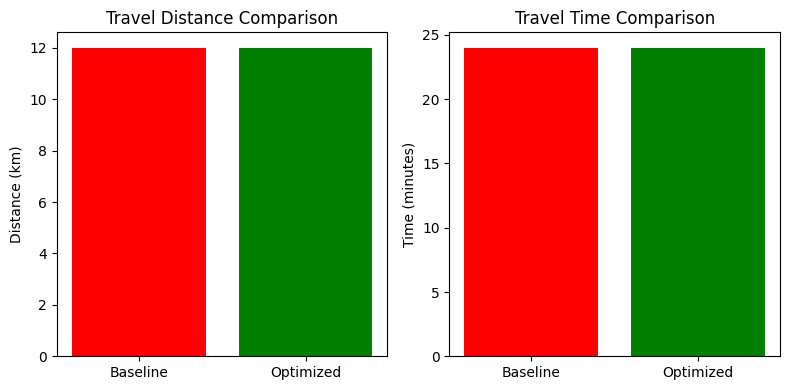

In [1]:
# -----------------------------------------------------------
# Garbage Collection Routing : Dijkstra-Based Optimization
# -----------------------------------------------------------

import heapq                               # For implementing priority queue in Dijkstra
import numpy as np                          # For numerical storage
import matplotlib.pyplot as plt             # For final comparison graph

# -----------------------------
# 1. Create City Graph (Nodes + Edges)
# -----------------------------

# Each node is an area in the city.
# Edges represent roads with distances (in km).

graph = {
    'A': {'B': 4, 'C': 2},                   # A connected to B (4 km), C (2 km)
    'B': {'A': 4, 'D': 5, 'E': 10},          # B connections
    'C': {'A': 2, 'D': 8},                  # C connections
    'D': {'B': 5, 'C': 8, 'E': 2},          # D connections
    'E': {'B': 10, 'D': 2}                  # E connections
}

# Garbage pickup points
pickup_points = ['A', 'C', 'E']             # Locations where garbage must be collected

# Starting point of garbage truck
start = 'A'

# -----------------------------
# 2. Dijkstra Function (Shortest Path)
# -----------------------------

def dijkstra(graph, start):
    distances = {node: float('inf') for node in graph}  # Initialize all distances as infinity
    distances[start] = 0                                 # Distance from start to itself is 0

    pq = [(0, start)]                                    # Priority queue (distance, node)

    while pq:                                            # Continue until queue is empty
        curr_dist, node = heapq.heappop(pq)              # Get node with smallest distance

        if curr_dist > distances[node]:                  # Skip outdated entries
            continue

        for neighbor, weight in graph[node].items():     # Loop through neighbors
            new_dist = curr_dist + weight                # Calculate possible new distance

            if new_dist < distances[neighbor]:           # If shorter path found
                distances[neighbor] = new_dist           # Update distance
                heapq.heappush(pq, (new_dist, neighbor)) # Push updated distance into queue

    return distances                                      # Return map of all shortest distances

# -----------------------------
# 3. Baseline Route (Naive: Visit in Given Order)
# -----------------------------

baseline_distance = 0                                     # Store naive route length
order = ['A', 'C', 'E']                                   # Fixed route order

for i in range(len(order) - 1):
    shortest = dijkstra(graph, order[i])                  # Find shortest paths from current node
    baseline_distance += shortest[order[i + 1]]           # Add distance to next node

baseline_time = baseline_distance / 30 * 60               # Assume truck speed = 30 km/h → convert to minutes

# -----------------------------
# 4. Optimized Route: Find Best Visiting Order (Brute Force)
# -----------------------------

import itertools                                           # For generating route permutations

best_distance = float('inf')                               # Track minimum distance
best_route = None                                          # Track best visiting order

for perm in itertools.permutations(pickup_points):          # Try all visiting orders
    if perm[0] != start:                                    # Route must start at the truck's start
        continue

    dist = 0                                                # Distance for this permutation

    for i in range(len(perm) - 1):
        shortest = dijkstra(graph, perm[i])                # Compute shortest paths
        dist += shortest[perm[i + 1]]                      # Add distance to next pickup point

    if dist < best_distance:                               # Keep the smallest route
        best_distance = dist
        best_route = perm

optimized_time = best_distance / 30 * 60                   # Convert to minutes (30 km/h)

# -----------------------------
# 5. Print Results
# -----------------------------

print("Baseline route:", order)
print("Baseline travel distance:", baseline_distance, "km")
print("Baseline time:", baseline_time, "minutes")

print("\nOptimized route:", best_route)
print("Optimized travel distance:", best_distance, "km")
print("Optimized time:", optimized_time, "minutes")

# -----------------------------
# 6. Comparison Graph
# -----------------------------

labels = ["Baseline", "Optimized"]                         # Two categories
distance_values = [baseline_distance, best_distance]       # Distances
time_values = [baseline_time, optimized_time]              # Travel times

plt.figure(figsize=(8, 4))                                 # Plot size

plt.subplot(1, 2, 1)                                       # Left plot: Distance
plt.bar(labels, distance_values, color=["red", "green"])
plt.title("Travel Distance Comparison")
plt.ylabel("Distance (km)")

plt.subplot(1, 2, 2)                                       # Right plot: Time
plt.bar(labels, time_values, color=["red", "green"])
plt.title("Travel Time Comparison")
plt.ylabel("Time (minutes)")

plt.tight_layout()                                         # Adjust spacing
plt.show()                                                 # Display the plots
